# **CLIP(Vision Transformer)**

## 1.환경준비

### (1)라이브러리 로딩

In [1]:
import os, csv
import torch
from torchvision.datasets import CocoDetection
from torchvision import transforms
import matplotlib.pyplot as plt
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

### (2) 디바이스 설정

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 2.CLIP 사용해보기

### (1) 모델 다운로드

In [3]:
# 모델 다운로드
model_id = "openai/clip-vit-base-patch32"
processor = CLIPProcessor.from_pretrained(model_id)
model = CLIPModel.from_pretrained(model_id).to(device)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

### (2) 모델 사용

#### 1)이미지와 문장 준비

In [4]:
from google.colab import files
uploaded = files.upload()   # 로컬 PC에서 dog.jpg 선택

Saving dog.jpg to dog.jpg


In [5]:
img_path = "dog.jpg"
image = Image.open(img_path).convert("RGB")

# 캡션 후보 (텍스트 프롬프트)
texts = [
    "a dog playing in the park",
    "a cat sleeping on the sofa",
    "a person riding a bicycle",
    "a bowl of ramen on the table"
]

#### 2)전처리 및 유사도 계산

In [6]:
with torch.no_grad():
    inputs = processor(text=texts, images=image, return_tensors="pt", padding=True).to(device)
    outputs = model(**inputs)
    # CLIP은 이미지/텍스트 임베딩을 같은 공간으로 보냄
    image_embeds = outputs.image_embeds / outputs.image_embeds.norm(p=2, dim=-1, keepdim=True)
    text_embeds  = outputs.text_embeds  / outputs.text_embeds.norm(p=2, dim=-1, keepdim=True)

    # 코사인 유사도(배치: 1 x N문장) -> torch.Size([1, len(texts)])
    sims = image_embeds @ text_embeds.T
    best_idx = sims.argmax(dim=1).item()

print(f"이미지와 가장 잘 어울리는 문장: {texts[best_idx]}")
print("유사도 점수들:", sims.squeeze(0).tolist())

이미지와 가장 잘 어울리는 문장: a dog playing in the park
유사도 점수들: [0.2670038938522339, 0.1123088151216507, 0.18386071920394897, 0.154665008187294]


In [7]:
text_embeds

tensor([[-0.0370,  0.0201, -0.0052,  ..., -0.0190, -0.0375, -0.0186],
        [ 0.0411, -0.0064, -0.0792,  ...,  0.0316, -0.0643,  0.0098],
        [ 0.0025,  0.0122,  0.0031,  ..., -0.0149,  0.0181, -0.0578],
        [-0.0324,  0.0110,  0.0116,  ...,  0.0211, -0.0331, -0.0430]],
       device='cuda:0')

#### 3)제로샷 분류

In [8]:
# 제로샷 분류(라벨 후보를 문장 프롬프트로 만들어 비교)
# 제대로 하려면 라벨을 프롬프트 템플릿에 끼워 넣는 것이 일반적 (예: "a photo of a {label}")
labels = ["dog", "cat", "bicycle", "ramen"]
label_prompts = [f"a photo of a {c}" for c in labels]

with torch.no_grad():
    inputs = processor(text=label_prompts, images=image, return_tensors="pt", padding=True).to(device)
    outputs = model(**inputs)
    pred_img = outputs.image_embeds / outputs.image_embeds.norm(p=2, dim=-1, keepdim=True)
    pred_txt = outputs.text_embeds  / outputs.text_embeds.norm(p=2, dim=-1, keepdim=True)
    pred_sims = (pred_img @ pred_txt.T).squeeze(0)  # shape: [num_labels]
    pred_idx = int(torch.argmax(pred_sims).item())

print(f"제로샷 분류 결과: {labels[pred_idx]}")
for i, (lab, sc) in enumerate(zip(labels, pred_sims.tolist())):
    print(f"- {lab:8s}: {sc:.4f}")

제로샷 분류 결과: dog
- dog     : 0.2619
- cat     : 0.2027
- bicycle : 0.1796
- ramen   : 0.1644


### (3) 실습
* 원하는 이미지와 문장을 준비 합니다.
    * 이미지는 사물, 동물
    * 문장은 최소 3~5개 영문으로 준비

In [9]:
from google.colab import files
uploaded = files.upload()

Saving dog.jpg to dog (1).jpg


In [10]:
img_path = "dog.jpg"  # 준비한 이미지
image = Image.open(img_path).convert("RGB")

# 캡션 후보 (텍스트 프롬프트)
texts = [
    "a dog playing in the park",
    "a cat sleeping on the sofa",
    "a person riding a bicycle",
    "a bowl of ramen on the table"
]

* 이미지와 문장 간 유사도 계산

In [11]:
with torch.no_grad():
    inputs = processor(text=texts, images=image, return_tensors="pt", padding=True).to(device)
    outputs = model(**inputs)
    image_embeds = outputs.image_embeds / outputs.image_embeds.norm(p=2, dim=-1, keepdim=True)
    text_embeds  = outputs.text_embeds  / outputs.text_embeds.norm(p=2, dim=-1, keepdim=True)
    sims = image_embeds @ text_embeds.T
    best_idx = sims.argmax(dim=1).item()

print(f"이미지와 가장 잘 어울리는 문장: {texts[best_idx]}")
print("유사도 점수들:", sims.squeeze(0).tolist())

이미지와 가장 잘 어울리는 문장: a dog playing in the park
유사도 점수들: [0.2670038938522339, 0.1123088151216507, 0.18386071920394897, 0.154665008187294]


* 제로샷 분류
    * 이미지의 정답을 포함한 레이블 구성
    * 이미지 제로샷 분류 수행

In [12]:
labels = ["dog", "cat", "bicycle", "ramen"]
label_prompts = [f"a photo of a {c}" for c in labels]

with torch.no_grad():
    inputs = processor(text=label_prompts, images=image, return_tensors="pt", padding=True).to(device)
    outputs = model(**inputs)
    pred_img = outputs.image_embeds / outputs.image_embeds.norm(p=2, dim=-1, keepdim=True)
    pred_txt = outputs.text_embeds  / outputs.text_embeds.norm(p=2, dim=-1, keepdim=True)
    pred_sims = (pred_img @ pred_txt.T).squeeze(0)  # shape: [num_labels]
    pred_idx = int(torch.argmax(pred_sims).item())

print(f"제로샷 분류 결과: {labels[pred_idx]}")
for i, (lab, sc) in enumerate(zip(labels, pred_sims.tolist())):
    print(f"- {lab:8s}: {sc:.4f}")

제로샷 분류 결과: dog
- dog     : 0.2619
- cat     : 0.2027
- bicycle : 0.1796
- ramen   : 0.1644


## 3.이미지 태깅(레이블링)

* CLIP을 이용해서 이미지에 태그를 달아 봅시다.

### (1) 데이터 준비

* cocodataset2017 소개
    * 규모: 약 33만 장의 이미지와 250만 개 이상의 객체 인스턴스 포함
    * 클래스: 80개 객체 카테고리(사람, 동물, 차량, 가전제품, 음식 등 일상적인 사물)
    * 라벨: 객체 경계 상자(bounding box), 세그멘테이션 마스크, 키포인트(예: 사람 관절 위치), 자연어 캡션(이미지 설명 문장) 제공
    
* 데이터 다운로드 및 압축 풀기(약 2~3분 소요)

In [13]:
!wget http://images.cocodataset.org/zips/val2017.zip
!wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip

!unzip val2017.zip -d ./coco/
!unzip annotations_trainval2017.zip -d ./coco/

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
 extracting: ./coco/val2017/000000365745.jpg  
 extracting: ./coco/val2017/000000320425.jpg  
 extracting: ./coco/val2017/000000481404.jpg  
 extracting: ./coco/val2017/000000314294.jpg  
 extracting: ./coco/val2017/000000335328.jpg  
 extracting: ./coco/val2017/000000513688.jpg  
 extracting: ./coco/val2017/000000158548.jpg  
 extracting: ./coco/val2017/000000132116.jpg  
 extracting: ./coco/val2017/000000415238.jpg  
 extracting: ./coco/val2017/000000321333.jpg  
 extracting: ./coco/val2017/000000081738.jpg  
 extracting: ./coco/val2017/000000577584.jpg  
 extracting: ./coco/val2017/000000346905.jpg  
 extracting: ./coco/val2017/000000433980.jpg  
 extracting: ./coco/val2017/000000228144.jpg  
 extracting: ./coco/val2017/000000041872.jpg  
 extracting: ./coco/val2017/000000117492.jpg  
 extracting: ./coco/val2017/000000368900.jpg  
 extracting: ./coco/val2017/000000376900.jpg  
 extracting: ./coco/val2017/000000352491.jpg  
 extracting: ./coco/val2

* 데이터 100건만 샘플링해서 태깅을 수행해 봅니다.

In [14]:
# 경로 설정
coco_root = "./coco/val2017"
ann_file  = "./coco/annotations/instances_val2017.json"

# CocoDetection 로드
dataset = CocoDetection(root=coco_root, annFile=ann_file)

loading annotations into memory...
Done (t=0.51s)
creating index...
index created!


In [15]:
# 100장만 사용
subset = [dataset[i] for i in range(100)]

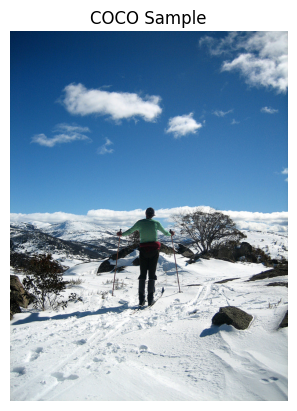

In [16]:
i = 30
img, ann = subset[i]
plt.imshow(img)
plt.axis("off")
plt.title("COCO Sample")
plt.show()

### (2) 모델 준비

In [17]:
model_id = "openai/clip-vit-base-patch32"
processor = CLIPProcessor.from_pretrained(model_id)
model = CLIPModel.from_pretrained(model_id).to(device)

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

In [18]:
# 환경
top_k = 5          # 이미지당 태그 최대 개수
thr = 0.01         # 과태깅 방지 임계값. None이면 미사용

In [19]:
# 클래스 레이블 준비(태그)
coco80 = [
    "person","bicycle","car","motorcycle","airplane","bus","train","truck","boat","traffic light",
    "fire hydrant","stop sign","parking meter","bench","bird","cat","dog","horse","sheep","cow",
    "elephant","bear","zebra","giraffe","backpack","umbrella","handbag","tie","suitcase","frisbee",
    "skis","snowboard","sports ball","kite","baseball bat","baseball glove","skateboard","surfboard","tennis racket","bottle",
    "wine glass","cup","fork","knife","spoon","bowl","banana","apple","sandwich","orange",
    "broccoli","carrot","hot dog","pizza","donut","cake","chair","couch","potted plant","bed",
    "dining table","toilet","tv","laptop","mouse","remote","keyboard","cell phone","microwave","oven",
    "toaster","sink","refrigerator","book","clock","vase","scissors","teddy bear","hair drier","toothbrush"
]


In [20]:
prompts = [f"A photo of a {l}" for l in coco80]

### (3) 태깅

In [21]:
@torch.no_grad()  # 데코레이터. 함수 안에서 실행되는 모든 연산이 autograd(자동 미분)을 기록하지 않음
def tag_image(img: Image.Image, top_k=5):
    inputs = processor(text=prompts, images=img, return_tensors="pt", padding=True).to(device)
    out = model(**inputs)
    sims = out.logits_per_image.softmax(dim=1)[0].cpu()  # [80]
    vals, idxs = torch.topk(sims, k=top_k)
    tags = [(coco80[i], float(vals[j])) for j, i in enumerate(idxs)]
    return tags

In [22]:
os.makedirs("coco_out", exist_ok=True)
csv_path = "coco_out/coco_clip_tags_0_100.csv"

with open(csv_path, "w", newline="", encoding="utf-8") as f:
    wr = csv.writer(f)
    wr.writerow(["idx", "file", "topk_tags", "scores"])
    for i, (img, ann) in enumerate(subset):
        # 태깅
        tags = tag_image(img, top_k=5)

        # 저장용 파일 경로
        out_path = f"coco_out/val_{i:03d}.jpg"
        img.save(out_path)

        # CSV 기록
        wr.writerow([i, out_path,
                     "|".join([t for t, _ in tags]),
                     "|".join([f"{s:.4f}" for _, s in tags])])

        # 10장 정도만 시각화 예시
        if i < 10:
            plt.imshow(img)
            plt.axis("off")
            title = ", ".join([f"{t}:{s:.2f}" for t, s in tags])
            plt.title(title, fontsize=9)
            plt.show()

print(f"완료: {csv_path} (썸네일은 coco_out/에 저장됨)")

Output hidden; open in https://colab.research.google.com to view.

### (4) 실습

* 다양한 object가 있는 이미지를 업로드 합니다.

In [23]:
from google.colab import files
uploaded = files.upload()

Saving dog_cat.jpg to dog_cat.jpg


In [24]:
img_path = "dog_cat.jpg"
img = Image.open(img_path).convert("RGB")

* tag_image 함수를 사용하여 태깅을 수행해 봅시다.(top_k, thr 값 조정)

In [25]:
prompts

['A photo of a person',
 'A photo of a bicycle',
 'A photo of a car',
 'A photo of a motorcycle',
 'A photo of a airplane',
 'A photo of a bus',
 'A photo of a train',
 'A photo of a truck',
 'A photo of a boat',
 'A photo of a traffic light',
 'A photo of a fire hydrant',
 'A photo of a stop sign',
 'A photo of a parking meter',
 'A photo of a bench',
 'A photo of a bird',
 'A photo of a cat',
 'A photo of a dog',
 'A photo of a horse',
 'A photo of a sheep',
 'A photo of a cow',
 'A photo of a elephant',
 'A photo of a bear',
 'A photo of a zebra',
 'A photo of a giraffe',
 'A photo of a backpack',
 'A photo of a umbrella',
 'A photo of a handbag',
 'A photo of a tie',
 'A photo of a suitcase',
 'A photo of a frisbee',
 'A photo of a skis',
 'A photo of a snowboard',
 'A photo of a sports ball',
 'A photo of a kite',
 'A photo of a baseball bat',
 'A photo of a baseball glove',
 'A photo of a skateboard',
 'A photo of a surfboard',
 'A photo of a tennis racket',
 'A photo of a bottle

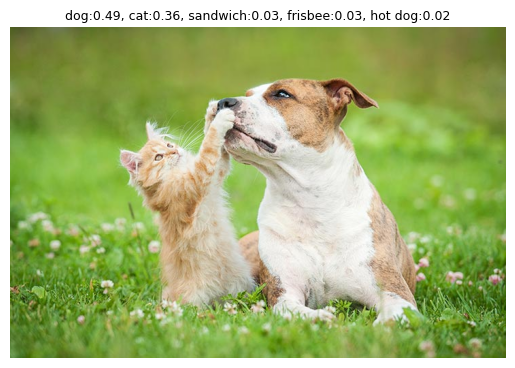

Top tags:
- dog             : 0.4868
- cat             : 0.3643
- sandwich        : 0.0288
- frisbee         : 0.0261
- hot dog         : 0.0194


In [26]:
import matplotlib.pyplot as plt

top_k = 5   # 상위 태그 개수
thr   = 0.01  # 낮은 점수 걸러내기. None이면 사용 안 함

tags = tag_image(img, top_k=top_k)

plt.imshow(img)
plt.axis("off")
plt.title(", ".join([f"{t}:{s:.2f}" for t, s in tags]), fontsize=9)
plt.show()

print("Top tags:")
for t, s in tags:
    print(f"- {t:15s} : {s:.4f}")